##### Questions to be answered from this analysis

<span style="font-size:12px">

1. How do accident percentages vary by month, Do accident counts fluctuate and indicate seasonal patterns in the data?
2. What is the number of incidents on each day of the week and hour of the day, and during which time of the day are accidents the most frequent?
3. On which street do most number of accidents occur, and what percentage of the actual reported did that specific street account?
4. Which factor attributes to be the most common contributing factor for Vehicle 1, and more specifically, what is the most common contributing factor to the most serious incidents?
</span>


#### Libararies

In [32]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [33]:
VISUALS_DIR = Path.cwd().parent / 'visuals' if Path.cwd().name == 'notebooks' else Path('visuals')
EXPORTS_DIR = Path.cwd().parent / 'exports' if Path.cwd().name == 'notebooks' else Path('exports')

VISUALS_DIR.mkdir(parents=True, exist_ok=True)
EXPORTS_DIR.mkdir(parents=True, exist_ok=True)

#### Dataset

In [34]:
DATA_DIR = Path.cwd().parent / 'data' if Path.cwd().name == 'notebooks' else Path('data')

df = pd.read_csv(DATA_DIR / 'cleaned.csv')

In [35]:
df.head()

,crash_date,crash_time,borough,zip_code,latitude,longitude,location,on_street_name,cross_street_name,off_street_name,...,vehicle_type_code_1,vehicle_type_code_2,vehicle_type_code_3,vehicle_type_code_4,vehicle_type_code_5,month_of_crash,day_of_crash,hour_of_crash,street_of_crash,is_fatal
0,2020-08-29,1900-01-01 15:40:00,BRONX,10466.0,40.89210,-73.833760,POINT (-73.83376 40.8921),PRATT AVENUE,STRANG AVENUE,NaN,...,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,Aug,Saturday,15,PRATT AVENUE,False
1,2020-08-29,1900-01-01 21:00:00,BROOKLYN,11221.0,40.69050,-73.919914,POINT (-73.919914 40.6905),BUSHWICK AVENUE,PALMETTO STREET,NaN,...,Sedan,Sedan,NaN,NaN,NaN,Aug,Saturday,21,BUSHWICK AVENUE,False
2,2020-08-29,1900-01-01 18:20:00,NaN,NaN,40.81650,-73.946556,POINT (-73.946556 40.8165),8 AVENUE,NaN,NaN,...,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN,Aug,Saturday,18,8 AVENUE,False
3,2020-08-29,1900-01-01 00:00:00,BRONX,10459.0,40.82472,-73.892960,POINT (-73.89296 40.82472),NaN,NaN,1047 SIMPSON STREET,...,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,Sedan,Motorcycle,NaN,Aug,Saturday,0,NAN,False
4,2020-08-29,1900-01-01 17:10:00,BROOKLYN,11203.0,40.64989,-73.933890,POINT (-73.93389 40.64989),NaN,NaN,4609 SNYDER AVENUE,...,Sedan,Sedan,NaN,NaN,NaN,Aug,Saturday,17,NAN,False


#### Question 1: How do accident percentages vary by month, Do accident counts fluctuate and indicate seasonal patterns in the data?

In [36]:
month_order = df.sort_values("crash_date")["month_of_crash"].unique()

In [37]:
month_order

array(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug'],
      dtype=object)

In [38]:
monthly_crash_pct = (
    (df["month_of_crash"].value_counts(normalize=True) * 100).reindex(month_order).round(2)
)

In [39]:
monthly_crash_pct

month_of_crash
Jan    19.08
Feb    18.27
Mar    14.77
Apr     5.50
May     8.21
Jun    10.17
Jul    12.32
Aug    11.68
Name: proportion, dtype: float64

###### Visuals (Monthly Crash Percentage)

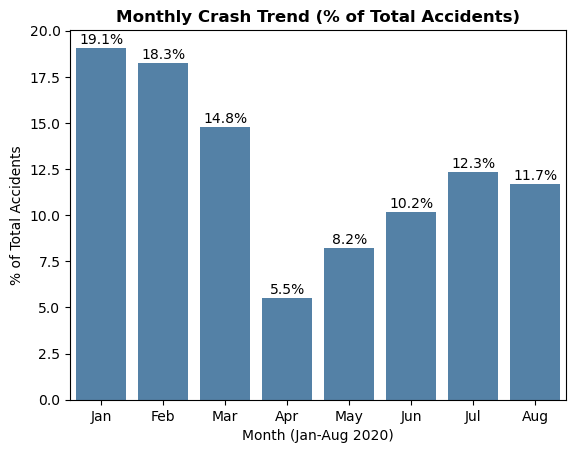

In [40]:
ax = sns.barplot(x=monthly_crash_pct.index, y=monthly_crash_pct.values, color='steelblue')

first_month = month_order[0]
last_month = month_order[-1]

plt.title("Monthly Crash Trend (% of Total Accidents)", fontweight='bold')
plt.xlabel(f'Month ({first_month}-{last_month} 2020)')
plt.ylabel('% of Total Accidents')


for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center', 
        va='center',
        xytext=(0,6),
        textcoords='offset points',
    )

plt.savefig(VISUALS_DIR / "1. monthly_crash_trend.png", dpi=300, bbox_inches="tight")

plt.show()

###### Insight from Data

<span style="font-size:12px"> 
Mid-period contraction is clearly evident in comparing the distribution of crashes on a calendar month basis for the period, indicating no normal seasonality. Winter months of January (19.1%) and February (18.3%) are responsible for close to 37.4% of total crashes during the period, being the most crash prone. Entering spring volume of crashes sharply declined hitting the absolute trough of 5.5% (reduction of 71.2% from January) in April. Recovery of crashes were ongoing from May (8.2%) through July (12.3%) stabilizing at 11.7% in August, although still lower than the crash level of start of year.
    </span>

###### Export Result for Visualization Tool

In [41]:
monthly_crash_pct.name = "percentage_of_crash"

In [42]:
monthly_crash_pct.to_csv(EXPORTS_DIR / "monthly_crash_pct.csv", index=True)

#### Question 2: What is the number of incidents on each day of the week and hour of the day, and during which time of the day are accidents the most frequent?

In [43]:
day_order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [44]:
day_order

['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [45]:
day_hour_matrix = (df.groupby(["day_of_crash", "hour_of_crash"]).size().unstack().reindex(day_order))

In [46]:
day_hour_matrix

hour_of_crash,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_crash,,,,,,,,,,,,,,,,,,,,,
Monday,385,200,126,112,117,142,310,407,591,552,...,682,690,746,736,658,494,373,325,278,219
Tuesday,333,134,88,96,78,159,294,433,643,576,...,719,654,799,750,693,509,444,326,339,264
Wednesday,367,154,129,106,103,176,258,407,563,509,...,741,730,756,743,688,520,402,378,366,259
Thursday,391,144,116,78,118,148,316,445,679,593,...,722,683,814,778,703,556,454,399,340,283
Friday,436,200,150,111,115,178,315,383,648,638,...,815,781,870,804,800,628,574,472,430,428
Saturday,526,330,259,232,212,180,193,223,323,330,...,722,602,668,624,628,569,484,455,439,419
Sunday,510,312,271,254,232,195,182,165,231,241,...,615,537,566,539,526,462,407,356,365,292


###### Peak Times Accident Occur Most Frequently

In [47]:
peak_window = df.groupby(["day_of_crash", "hour_of_crash"]).size().idxmax()

In [48]:
peak_window

('Friday', np.int64(16))

<function matplotlib.pyplot.show(close=None, block=None)>

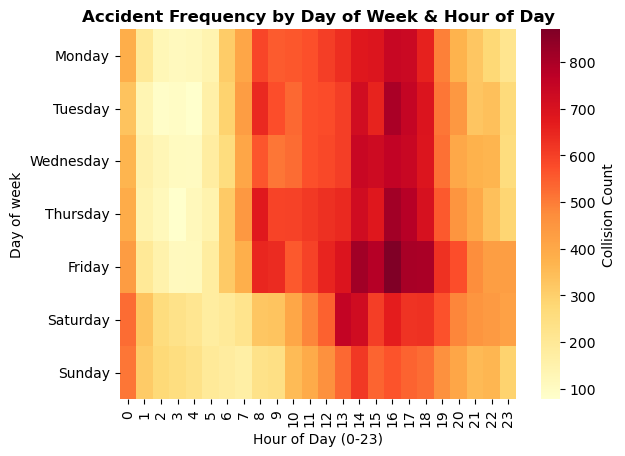

In [49]:
sns.heatmap(day_hour_matrix, cmap='YlOrRd', cbar_kws={'label': 'Collision Count'})

plt.title(
     'Accident Frequency by Day of Week & Hour of Day',
    fontweight='bold',
)

plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Day of week')


plt.savefig(VISUALS_DIR / "2. accident_frequency.png", dpi=300, bbox_inches="tight")

plt.show

##### Insight from the data

<span style="font-size:12px"> 
Traffic accidents show a clearly defined dual peak, strongly correlating with urban commuting patterns. The primary risk window emerges during the late afternoon 14:00-18:00 homeward commute, peaking absolutely at Friday, 16:00 (4:00 PM), with 870 collisions. Friday is the riskiest day overall (12271 crashes total), due to the effects of afternoon rush-hour traffic and weekend travel transitions. Although morning rush hours 08:00-09:00 pose a second bump, afternoon volume is nearly 3x as large, indicating that evening commute conditions drive most day's crash risk.
</span>

###### Export Result for visualisation tool

In [50]:
day_hour_matrix_formatted = day_hour_matrix.reset_index().melt(id_vars="day_of_crash", 
                                var_name="hour_of_crash", 
                                value_name="crash_count")

In [51]:
day_hour_matrix_formatted

,day_of_crash,hour_of_crash,crash_count
0,Monday,0,385
1,Tuesday,0,333
2,Wednesday,0,367
3,Thursday,0,391
4,Friday,0,436
...,...,...,...
163,Wednesday,23,259
164,Thursday,23,283
165,Friday,23,428
166,Saturday,23,419


In [52]:
day_hour_matrix_formatted.to_csv(EXPORTS_DIR / "day_hour_matrix_formatted.csv", index=False)

#### Question 3: On which street do most number of accidents occur, and what percentage of the actual reported did that specific street account?


In [53]:
df["on_street_name"].isna().any()

np.True_

In [54]:
valid_streets = df[
    df["on_street_name"].notna() & 
    ~df["on_street_name"].isin(['NAN', 'Unspecified', 'UNKNOWN', ''])
]["on_street_name"]
total_records = len(valid_streets)
street_counts = valid_streets.value_counts()

top_streets = (valid_streets.value_counts().head(8) / total_records) * 100

top_street = street_counts.index[0]
top_street_pct = round((street_counts.iloc[0] / total_records) * 100,2)


In [55]:
top_streets

on_street_name
BELT PARKWAY                  2.238294
LONG ISLAND EXPRESSWAY        1.343698
BROOKLYN QUEENS EXPRESSWAY    1.331073
FDR DRIVE                     1.313037
MAJOR DEEGAN EXPRESSWAY       1.065940
GRAND CENTRAL PKWY            1.047904
BROADWAY                      1.037082
ATLANTIC AVENUE               0.959527
Name: count, dtype: float64

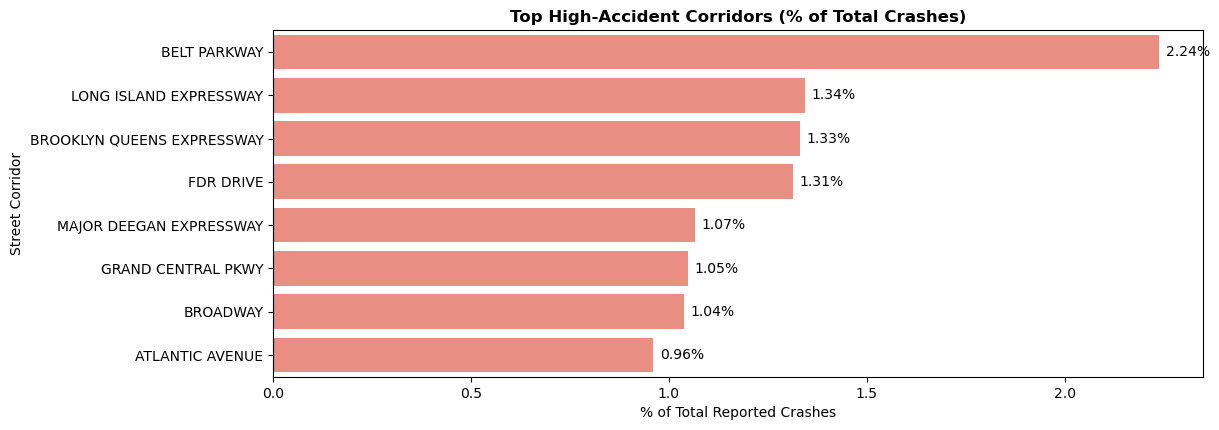

In [56]:
plt.figure(figsize=(12, 4.5))
ax = sns.barplot(x=top_streets.values, y=top_streets.index, color="salmon")

plt.title(
    'Top High-Accident Corridors (% of Total Crashes)',
    fontweight='bold',
)
plt.xlabel('% of Total Reported Crashes')
plt.ylabel('Street Corridor')

for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.2f}%',
        (p.get_width(), p.get_y() + p.get_height() / 2.0),
        ha='left',
        va='center',
        xytext=(5, 0),
        textcoords='offset points',
    )

plt.savefig(VISUALS_DIR / "3. top_high_accident.png", dpi=300, bbox_inches="tight")
plt.show()

##### Insight from the data

<span style="font-size:12px"> 
Belt Parkway recorded the highest number of accidents across New york city during the sample period, Belt parkway accounted for 2.24% of all reported citywide collisions during the sample period
</span>

###### Export Result for visualisation tool

In [57]:
top_streets.to_csv(EXPORTS_DIR / "top_streets.csv", index=True)

#### Question 4: Which factor attributes to be the most common contributing factor for Vehicle 1, and more specifically, what is the most common contributing factor to the most serious incidents?

In [58]:
valid_factors = df[
        ~df["contributing_factor_vehicle_1"].isin(
            ["Unspecified", np.nan, "NAN"]
        )
    ]
top_factor_overall = (
        valid_factors["contributing_factor_vehicle_1"]
        .value_counts()
        .idxmax()
    )

fatal_subset = valid_factors[valid_factors["is_fatal"] == True]
top_factor_fatal = (
        fatal_subset["contributing_factor_vehicle_1"].value_counts().idxmax()
    )
    

##### Before computing contributing factor proportions, generic and uninformative entries (such as "Unspecified") were filtered out in order to isolate actionable insights.

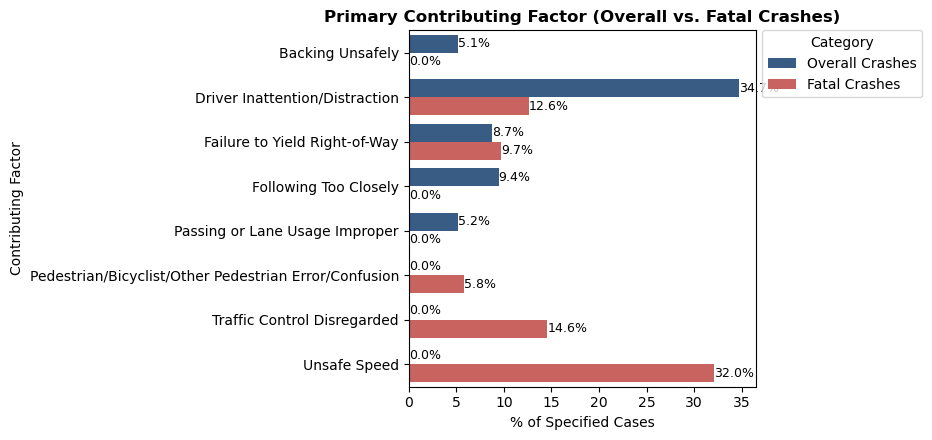

In [59]:

valid_factors = df[
    ~df["contributing_factor_vehicle_1"].isin(
        ["Unspecified", np.nan, "NAN", "Unknown"]
    )
]


top_factor_overall = valid_factors["contributing_factor_vehicle_1"].value_counts().idxmax()

fatal_subset = valid_factors[valid_factors["is_fatal"] == True]
top_factor_fatal = fatal_subset["contributing_factor_vehicle_1"].value_counts().idxmax()


overall_f = (
    valid_factors['contributing_factor_vehicle_1']
    .value_counts(normalize=True)
    .head(5) * 100
)

fatal_f = (
    valid_factors[valid_factors['is_fatal']]['contributing_factor_vehicle_1']
    .value_counts(normalize=True)
    .head(5) * 100
)


comp_df = pd.DataFrame({'Overall Crashes': overall_f, 'Fatal Crashes': fatal_f}).fillna(0)
comp_df['Factor'] = comp_df.index
comp_melted = pd.melt(
    comp_df,
    id_vars=['Factor'],
    value_vars=['Overall Crashes', 'Fatal Crashes'],
    var_name='Crash Type',
    value_name='Percentage',
)

plt.figure(figsize=(9.5, 4.5))
ax = sns.barplot(
    x='Percentage',
    y='Factor',
    hue='Crash Type',
    data=comp_melted,
    palette=['#2b5c8f', '#d9534f'],
)

plt.title(
    'Primary Contributing Factor (Overall vs. Fatal Crashes)',
    fontweight='bold',
)
plt.xlabel('% of Specified Cases')
plt.ylabel('Contributing Factor')


plt.legend(
    title='Category',
    bbox_to_anchor=(1.02, 1),  
    loc='upper left',
    borderaxespad=0
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9)

plt.savefig(VISUALS_DIR / "4. crash_factors.png", dpi=300, bbox_inches="tight")
plt.tight_layout()  
plt.show()



##### Insight from the data

<span style="font-size:12px"> 
The most frequent contributing factor for vehicle 1 crashes was driver inattention/distraction, which accounted for 34.7% of all stated collision reports across the dataset. For fatal incidents, unsafe speed accounted for 32.0% of all fatal collisions, the highest percentage of all factors included.
</span>

###### Export Result for visualisation tool

In [60]:
comp_df.to_csv(EXPORTS_DIR / "comp_df.csv")